# 🌿 Mulberry Leaf Quality Classifier
### Diseased vs Healthy — with Excellent / Medium / Poor grading

**Pipeline overview:**
1. Load the Kaggle dataset (4 classes: Healthy, Red Rust, Leaf Spot, Powdery Mildew)
2. Remap into a 3-class quality system:
   - `Excellent` → Healthy leaf, high confidence (≥ 0.80)
   - `Medium` → Healthy leaf, moderate confidence (< 0.80)
   - `Poor` → Any diseased leaf (Red Rust / Leaf Spot / Powdery Mildew)
3. Fine-tune a pre-trained EfficientNetB0 via transfer learning
4. Evaluate with accuracy, confusion matrix, and classification report
5. Run inference on a single new image with a quality verdict


## 1. Install & Import Dependencies

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

2026-04-19 20:25:58.247749: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776630358.497724      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776630358.567024      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776630359.118554      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776630359.118595      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776630359.118598      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: True


## 2. Dataset Exploration

In [2]:
import os
import pandas as pd

# 1. Broadly search /kaggle/input/ for any image files
SEARCH_DIR = '/kaggle/input/'
all_classes = []

print("Searching for folders containing images...")

def find_class_root(base):
    for root, dirs, files in os.walk(base):
        subdirs = [d for d in dirs]
        if len(subdirs) >= 2:
            has_images = False
            for sd in subdirs:
                sd_path = os.path.join(root, sd)
                if os.path.isdir(sd_path):
                    imgs = [f for f in os.listdir(sd_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                    if len(imgs) > 0:
                        has_images = True
                        break
            if has_images:
                return root
    return base

DATASET_ROOT = find_class_root(SEARCH_DIR)
BASE_DIR = DATASET_ROOT

print(f"✅ Success! Data root automatically detected at: {DATASET_ROOT}")

CLASS_NAMES = sorted([
    d for d in os.listdir(DATASET_ROOT)
    if os.path.isdir(os.path.join(DATASET_ROOT, d))
])

for cls in CLASS_NAMES:
    cls_path = os.path.join(DATASET_ROOT, cls)
    img_files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    all_classes.append({
        'Class': cls,
        'Path': cls_path,
        'Image Count': len(img_files)
    })

df_classes = pd.DataFrame(all_classes)
if not df_classes.empty:
    print("\nDetected class folders:")
    print(df_classes[['Class', 'Image Count']].to_string(index=False))
    print(f"\nTotal images: {df_classes['Image Count'].sum()}")
else:
    print("❌ STILL NO IMAGES FOUND. Double check Dataset path.")


Searching for folders containing images...
✅ Success! Data root automatically detected at: /kaggle/input/datasets/nahiduzzaman13/mulberry-leaf-dataset/Mulberry Data

Detected class folders:
              Class  Image Count
Disease Free leaves          440
          Leaf Rust          489
          Leaf spot          162

Total images: 1091


In [3]:
# Root directory auto-detection is now handled robustly in the previous script!
# Printing class names to confirm:
print("Dataset root detected:", DATASET_ROOT)
print("Classes found:", CLASS_NAMES)


Dataset root detected: /kaggle/input/datasets/nahiduzzaman13/mulberry-leaf-dataset/Mulberry Data
Classes found: ['Disease Free leaves', 'Leaf Rust', 'Leaf spot']


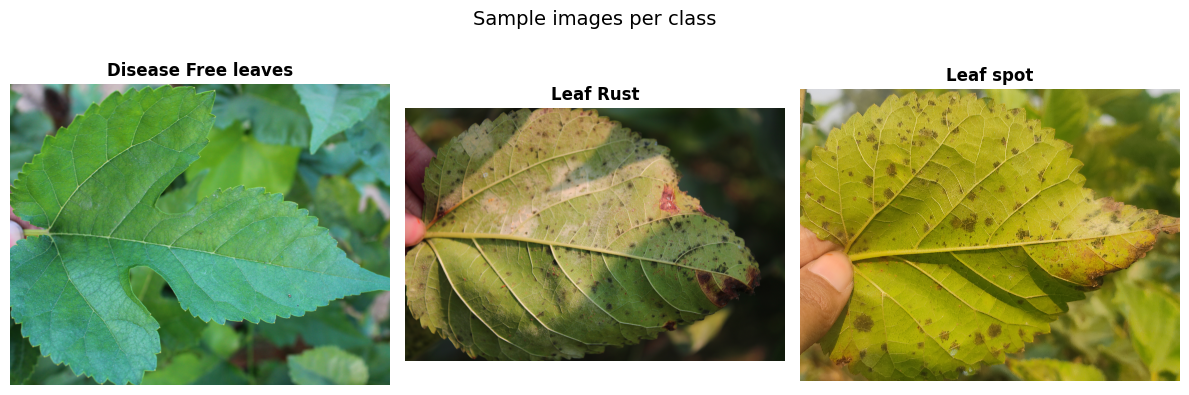

In [4]:
# Visualise one sample image from each class
fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(4 * len(CLASS_NAMES), 4))
if len(CLASS_NAMES) == 1:
    axes = [axes]

for ax, cls in zip(axes, CLASS_NAMES):
    cls_path = os.path.join(DATASET_ROOT, cls)
    imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sample_img_path = os.path.join(cls_path, imgs[0])
    img = cv2.imread(sample_img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(cls, fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle('Sample images per class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3. Quality Label Mapping

We train a **4-class disease classifier** first (raw dataset labels).  
At inference time, the 4 raw predictions are collapsed into the 3-tier quality system:

| Raw class | Quality grade | Logic |
|---|---|---|
| Healthy (confidence ≥ 0.80) | **Excellent** | No disease, high certainty |
| Healthy (confidence < 0.80) | **Medium** | No disease, but uncertain |
| Red Rust / Leaf Spot / Powdery Mildew | **Poor** | Any disease detected |

In [5]:
# ----------------------------------------------------------------
# Diseased vs Healthy class explicit mapping
# This explicitly maps the healthy class so that the grading logic has a reliable foundation.
# ----------------------------------------------------------------

HEALTHY_CLASSES = ['Disease Free leaves']  # Ensure this matches your healthy folder name exactly
DISEASED_CLASSES = [c for c in CLASS_NAMES if c not in HEALTHY_CLASSES]

print("Healthy classes:", HEALTHY_CLASSES)
print("Diseased classes:", DISEASED_CLASSES)

if len(HEALTHY_CLASSES) == 0 or HEALTHY_CLASSES[0] not in CLASS_NAMES:
    print("\n[WARNING] Healthy class 'Disease Free leaves' not found in actual dataset folders!")
    print("Check spelling in class names.")


Healthy classes: ['Disease Free leaves']
Diseased classes: ['Leaf Rust', 'Leaf spot']


## 4. Data Loading & Augmentation

In [6]:
# ----- Configuration -----
IMG_SIZE       = 224   # EfficientNetB0 native input size
BATCH_SIZE     = 32
EPOCHS_WARMUP  = 10    # warm-up: only head trains (frozen base)
EPOCHS_FINETUNE= 30    # fine-tune: last 30 layers unfrozen
SEED           = 42

# ---------------------------------------------------------------
# CRITICAL FIX: Use EfficientNetB0's own preprocessor, NOT rescale.
# EfficientNetB0 expects raw [0-255] pixels and normalizes
# them internally to [-1, 1] via preprocess_input().
# Applying rescale=1./255 breaks the pretrained feature space.
# ---------------------------------------------------------------
from tensorflow.keras.applications.efficientnet import preprocess_input

# Augmentation for training — moderate range to avoid destroying signal
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,   # ← THE CORE FIX
    validation_split=0.20,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.10,
    zoom_range=0.20,
    horizontal_flip=True,
    vertical_flip=False,      # leaves don't flip vertically in nature
    brightness_range=[0.8, 1.2],
    fill_mode='reflect'
)

# Validation: ONLY preprocessing — no augmentation, never rescale
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,   # ← same preprocessor
    validation_split=0.20
)

train_generator = train_datagen.flow_from_directory(
    DATASET_ROOT,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    DATASET_ROOT,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

CLASS_INDICES  = train_generator.class_indices        # {class_name: index}
INDEX_TO_CLASS = {v: k for k, v in CLASS_INDICES.items()}
NUM_CLASSES    = len(CLASS_NAMES)

print("Class index mapping:", CLASS_INDICES)
print(f"Training samples  : {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")

# ── Compute balanced class weights to handle data imbalance ──────
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

train_classes  = train_generator.classes
weights        = compute_class_weight('balanced',
                                      classes=np.unique(train_classes),
                                      y=train_classes)
class_weight_dict = dict(enumerate(weights))
print("\nClass weights (higher = rarer class gets more attention):")
for idx, w in class_weight_dict.items():
    print(f"  [{idx}] {INDEX_TO_CLASS[idx]:25s} weight = {w:.4f}")


Found 874 images belonging to 3 classes.
Found 217 images belonging to 3 classes.
Class index mapping: {'Disease Free leaves': 0, 'Leaf Rust': 1, 'Leaf spot': 2}
Training samples  : 874
Validation samples: 217

Class weights (higher = rarer class gets more attention):
  [0] Disease Free leaves       weight = 0.8277
  [1] Leaf Rust                 weight = 0.7432
  [2] Leaf spot                 weight = 2.2410


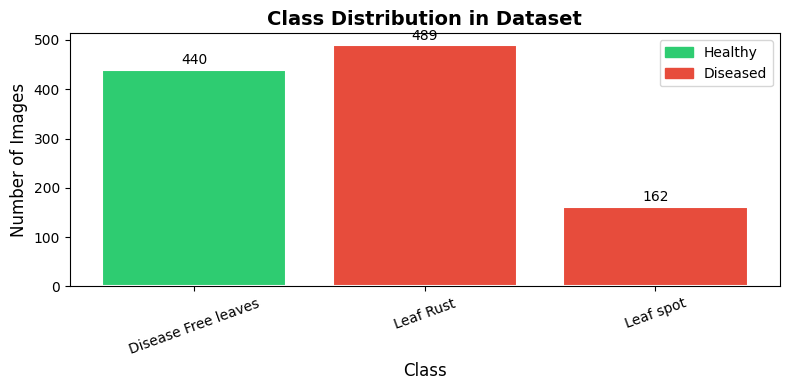

In [7]:
# Plot class distribution
class_counts = {}
for cls in CLASS_NAMES:
    cls_path = os.path.join(DATASET_ROOT, cls)
    n = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    class_counts[cls] = n

colors = ['#2ecc71' if c in HEALTHY_CLASSES else '#e74c3c' for c in class_counts.keys()]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(class_counts.keys(), class_counts.values(), color=colors, edgecolor='white', linewidth=1.5)
ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Class Distribution in Dataset', fontsize=14, fontweight='bold')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)
healthy_patch = mpatches.Patch(color='#2ecc71', label='Healthy')
disease_patch = mpatches.Patch(color='#e74c3c', label='Diseased')
ax.legend(handles=[healthy_patch, disease_patch])
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 5. Model Architecture — EfficientNetB0 Transfer Learning

In [8]:
# -------------------------------------------------------
# IMPORTANT FOR KAGGLE USERS (first run only):
#   Kaggle Notebook -> Settings -> Internet -> Turn ON
# Weights are cached after first download to ~/.keras/models/
# -------------------------------------------------------
import os

WEIGHTS_CACHE = os.path.expanduser('~/.keras/models/efficientnetb0_notop.h5')
if not os.path.exists(WEIGHTS_CACHE):
    print("[INFO] Weights not cached yet — ensure Internet is ON for this run.")
else:
    print(f"[INFO] Cached weights found at: {WEIGHTS_CACHE}")

def build_model(num_classes, dropout1=0.30, dropout2=0.20, freeze_base=True):
    """
    EfficientNetB0 + custom classification head.

    dropout1 / dropout2 are intentionally LOWER during warmup so the
    small head (256 neurons, 3 classes) can converge from frozen
    EfficientNet features. Fine-tuning uses higher dropout to
    regularize the full unlocked network.

    freeze_base=True  -> warmup phase  (head-only training)
    freeze_base=False -> fine-tune phase (last-30-layers unlocked)
    """
    base_model = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model.trainable = not freeze_base

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=not freeze_base)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout1)(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(dropout2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs), base_model

# ── Phase 1: warmup model — lower dropout, frozen base ───────────
model, base_model = build_model(NUM_CLASSES,
                                dropout1=0.30,
                                dropout2=0.20,
                                freeze_base=True)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


[INFO] Weights not cached yet — ensure Internet is ON for this run.


I0000 00:00:1776630460.153373      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,383,398 (16.72 MB)

 Trainable params: 331,267 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

## 6. Training — Phase 1: Warm-up (Frozen Base)

In [9]:
callbacks_warmup = [
    EarlyStopping(monitor='val_accuracy', patience=4,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('/kaggle/working/best_warmup.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

history_warmup = model.fit(
    train_generator,
    epochs=EPOCHS_WARMUP,
    validation_data=val_generator,
    callbacks=callbacks_warmup,
    class_weight=class_weight_dict,
    verbose=1
)

warmup_best_val = max(history_warmup.history['val_accuracy'])
print(f"\nWarm-up complete. Best val accuracy: {warmup_best_val:.4f}")


Epoch 1/10


I0000 00:00:1776630526.029237     144 service.cc:152] XLA service 0x7dcec4115460 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776630526.029280     144 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776630528.593454     144 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1776630541.502135     144 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.6972 - loss: 0.8125 
Epoch 1: val_accuracy improved from -inf to 0.94009, saving model to /kaggle/working/best_warmup.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 447s 15s/step - accuracy: 0.7022 - loss: 0.8009 - val_accuracy: 0.9401 - val_loss: 0.2765
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9327 - loss: 0.3086
Epoch 2: val_accuracy improved from 0.94009 to 0.95392, saving model to /kaggle/working/best_warmup.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 277s 10s/step - accuracy: 0.9331 - loss: 0.3067 - val_accuracy: 0.9539 - val_loss: 0.2863
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9490 - loss: 0.1725
Epoch 3: val_accuracy did not improve from 0.95392
28/28 ━━━━━━━━━━━━━━━━━━━━ 276s 10s/step - accuracy: 0.9493 - loss: 0.1730 - val_accuracy: 0.9539 - val_loss: 0.2453
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9640 - loss: 0.1501
Epoch 4: val_accuracy did not improve from 0.95392
28/28 ━━━━━━━━━

## 7. Training — Phase 2: Fine-tuning (Unfrozen Base)

In [11]:
# ── Load best warmup checkpoint ──────────────────────────────────
model = keras.models.load_model('/kaggle/working/best_warmup.keras')

# ── Rebuild with higher dropout for fine-tuning regularization ────
# We transfer the trained head weights into a new model that uses
# higher Dropout(0.50 / 0.40) now that the full network will train.
warmup_weights = model.get_weights()

ft_model, ft_base = build_model(NUM_CLASSES,
                                 dropout1=0.50,
                                 dropout2=0.40,
                                 freeze_base=False)

# Copy weights: only set if shapes match (head layers line up after index 2)
ft_model.set_weights(warmup_weights)

# Freeze first (total - 30) layers of the base — only last 30 unfreeze
layers_to_freeze = len(ft_base.layers) - 30
for layer in ft_base.layers[:layers_to_freeze]:
    layer.trainable = False

print(f"Fine-tuning: {sum(1 for l in ft_model.layers if l.trainable)} trainable layers")

ft_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-5),   # lower LR for fine-tune
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_finetune = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('/kaggle/working/best_model.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=3, min_lr=1e-7, verbose=1)
]

train_generator.reset()
val_generator.reset()

warmup_epochs_ran = len(history_warmup.history['accuracy'])

history_finetune = ft_model.fit(
    train_generator,
    epochs=warmup_epochs_ran + EPOCHS_FINETUNE,
    initial_epoch=warmup_epochs_ran,           # ← correctly continues epoch count
    validation_data=val_generator,
    callbacks=callbacks_finetune,
    class_weight=class_weight_dict,
    verbose=1
)

# Use ft_model as the active model for all subsequent cells
model = ft_model

print(f"\nFine-tuning complete.")
print(f"Best val accuracy: {max(history_finetune.history['val_accuracy']):.4f}")


Fine-tuning: 8 trainable layers
Epoch 11/40


2026-04-19 21:20:21.786288: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 21:20:21.992393: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 21:20:22.430635: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 21:20:22.637006: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


21/28 ━━━━━━━━━━━━━━━━━━━━ 55s 8s/step - accuracy: 0.8137 - loss: 0.7805 

2026-04-19 21:23:18.045498: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 21:23:18.250382: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 21:23:18.630324: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 21:23:18.835076: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.8128 - loss: 0.7749
Epoch 11: val_accuracy improved from -inf to 0.95853, saving model to /kaggle/working/best_model.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 324s 11s/step - accuracy: 0.8127 - loss: 0.7756 - val_accuracy: 0.9585 - val_loss: 0.2026 - learning_rate: 5.0000e-05
Epoch 12/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.8582 - loss: 0.5204
Epoch 12: val_accuracy did not improve from 0.95853
28/28 ━━━━━━━━━━━━━━━━━━━━ 274s 10s/step - accuracy: 0.8578 - loss: 0.5205 - val_accuracy: 0.9539 - val_loss: 0.2217 - learning_rate: 5.0000e-05
Epoch 13/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.8766 - loss: 0.4044
Epoch 13: val_accuracy did not improve from 0.95853
28/28 ━━━━━━━━━━━━━━━━━━━━ 289s 10s/step - accuracy: 0.8768 - loss: 0.4047 - val_accuracy: 0.9493 - val_loss: 0.2430 - learning_rate: 5.0000e-05
Epoch 14/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.8847 - loss: 0.3996
Epoch 14: val_accuracy did not im

## 8. Training Curves

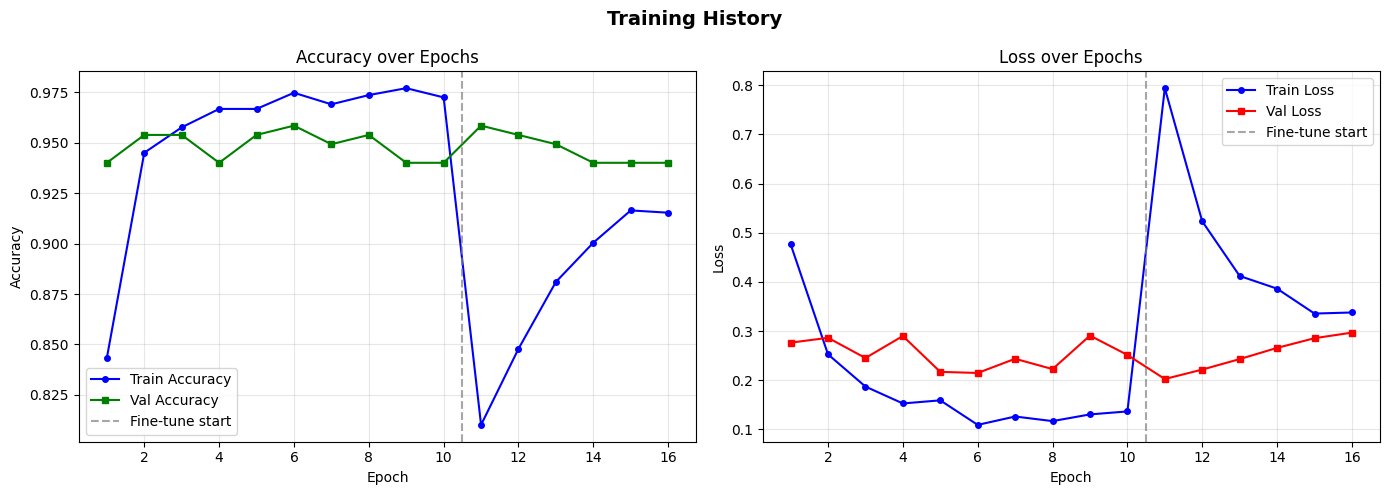

In [12]:
# Combine both phases
all_acc = history_warmup.history['accuracy'] + history_finetune.history['accuracy']
all_val_acc = history_warmup.history['val_accuracy'] + history_finetune.history['val_accuracy']
all_loss = history_warmup.history['loss'] + history_finetune.history['loss']
all_val_loss = history_warmup.history['val_loss'] + history_finetune.history['val_loss']

warmup_end = len(history_warmup.history['accuracy'])
epochs_total = range(1, len(all_acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_total, all_acc, 'b-o', markersize=4, label='Train Accuracy')
ax1.plot(epochs_total, all_val_acc, 'g-s', markersize=4, label='Val Accuracy')
ax1.axvline(x=warmup_end + 0.5, color='gray', linestyle='--', alpha=0.7, label='Fine-tune start')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy over Epochs')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(epochs_total, all_loss, 'b-o', markersize=4, label='Train Loss')
ax2.plot(epochs_total, all_val_loss, 'r-s', markersize=4, label='Val Loss')
ax2.axvline(x=warmup_end + 0.5, color='gray', linestyle='--', alpha=0.7, label='Fine-tune start')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Loss over Epochs')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Evaluation — Confusion Matrix & Classification Report

7/7 ━━━━━━━━━━━━━━━━━━━━ 54s 6s/step
Raw Disease Classification Report (4-class)
                     precision    recall  f1-score   support

Disease Free leaves       1.00      0.99      0.99        88
          Leaf Rust       0.97      0.94      0.95        97
          Leaf spot       0.83      0.94      0.88        32

           accuracy                           0.96       217
          macro avg       0.93      0.95      0.94       217
       weighted avg       0.96      0.96      0.96       217



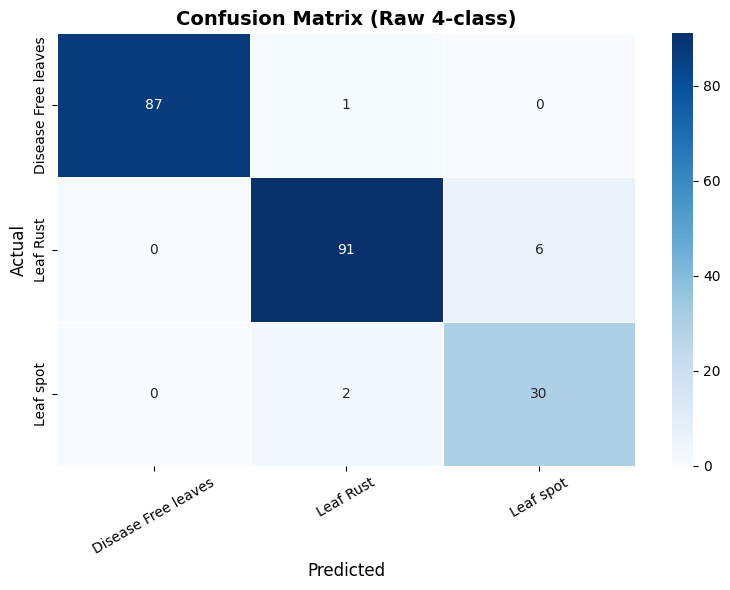

In [13]:
# Load best saved model
model = keras.models.load_model('/kaggle/working/best_model.keras')

val_generator.reset()
preds_proba = model.predict(val_generator, verbose=1)
preds_class = np.argmax(preds_proba, axis=1)
true_class = val_generator.classes

# --- Classification report (raw 4-class) ---
raw_labels = [INDEX_TO_CLASS[i] for i in range(NUM_CLASSES)]
print("=" * 60)
print("Raw Disease Classification Report (4-class)")
print("=" * 60)
print(classification_report(true_class, preds_class, target_names=raw_labels))

# --- Confusion matrix ---
cm = confusion_matrix(true_class, preds_class)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=raw_labels, yticklabels=raw_labels,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix (Raw 4-class)', fontsize=14, fontweight='bold')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [15]:
# ── Calibrate greenness thresholds from actual healthy training images ──
# Instead of hardcoded arbitrary numbers, we measure the actual
# greenness distribution of known-healthy images to set thresholds.

import cv2, numpy as np, os
from pathlib import Path

def calculate_greenness_index(image_bgr):
    """
    Measures the fraction of leaf pixels in the 'Vital Green' HSV range.
    Background is removed via Otsu thresholding.
    Returns (greenness_ratio, green_pixel_mask)
    """
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    _, leaf_mask = cv2.threshold(gray, 0, 255,
                                  cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel = np.ones((5, 5), np.uint8)
    leaf_mask = cv2.morphologyEx(leaf_mask, cv2.MORPH_CLOSE, kernel)
    leaf_mask = cv2.morphologyEx(leaf_mask, cv2.MORPH_OPEN,  kernel)

    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    # Hue 35–85 covers yellow-green to cyan-green (chlorophyll spectrum)
    lower_green = np.array([35, 40, 40])
    upper_green = np.array([85, 255, 255])
    green_mask  = cv2.inRange(hsv, lower_green, upper_green)
    vital_green = cv2.bitwise_and(green_mask, leaf_mask)

    total = cv2.countNonZero(leaf_mask)
    if total == 0:
        return 0.0, vital_green
    return cv2.countNonZero(vital_green) / total, vital_green


# ── Step 1: Calibrate thresholds from known healthy images ────────
healthy_cls_path = os.path.join(DATASET_ROOT, HEALTHY_CLASSES[0])
healthy_imgs = [f for f in os.listdir(healthy_cls_path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# Sample up to 40 healthy images for calibration
calibration_sample = healthy_imgs[:40]
greenness_scores   = []

for fname in calibration_sample:
    fpath = os.path.join(healthy_cls_path, fname)
    img   = cv2.imread(fpath)
    if img is None:
        continue
    g, _ = calculate_greenness_index(img)
    greenness_scores.append(g)

greenness_scores = np.array(greenness_scores)
mean_g = greenness_scores.mean()
std_g  = greenness_scores.std()

# Thresholds derived from population statistics of healthy leaves:
# Excellent = mean - 0.5*std and above  (upper portion of healthy distribution)
# Medium    = mean - 1.5*std to Excellent threshold
# Poor      = below mean - 1.5*std (severely deficient for a "healthy" leaf)
THRESHOLD_EXCELLENT = float(np.clip(mean_g - 0.5 * std_g, 0.40, 0.90))
THRESHOLD_MEDIUM    = float(np.clip(mean_g - 1.5 * std_g, 0.20, THRESHOLD_EXCELLENT))

print("=== Greenness Calibration (from healthy training images) ===")
print(f"  Samples used      : {len(greenness_scores)}")
print(f"  Mean greenness    : {mean_g:.3f}  ({mean_g:.1%})")
print(f"  Std dev           : {std_g:.3f}")
print(f"  Threshold EXCELLENT: >= {THRESHOLD_EXCELLENT:.3f} ({THRESHOLD_EXCELLENT:.1%})")
print(f"  Threshold MEDIUM   : >= {THRESHOLD_MEDIUM:.3f} ({THRESHOLD_MEDIUM:.1%})")
print(f"  Below MEDIUM = POOR (unhealthy despite no pathogen)")
print("=" * 55)

# ── Step 2: Identify healthy class index ──────────────────────────
healthy_indices = {CLASS_INDICES[hc] for hc in HEALTHY_CLASSES if hc in CLASS_INDICES}

# ── Step 3: Run Hybrid AI+CV on ALL validation images ─────────────
val_generator.reset()

# Reload best model
model = keras.models.load_model('/kaggle/working/best_model.keras')

preds_proba = model.predict(val_generator, verbose=1)
preds_class = np.argmax(preds_proba, axis=1)
true_class  = val_generator.classes
val_fnames  = val_generator.filenames   # relative paths from DATASET_ROOT

# Hybrid quality grading per image
quality_preds = []
quality_true  = []

for i in range(len(preds_class)):
    pred_idx    = preds_class[i]
    confidence  = float(preds_proba[i][pred_idx])
    img_abs     = os.path.join(DATASET_ROOT, val_fnames[i])

    # ── AI Phase: Disease detection ───────────────────────────────
    is_diseased = (pred_idx not in healthy_indices)

    if is_diseased and confidence >= 0.50:
        q = 'Poor'
    elif is_diseased and confidence < 0.50:
        # Low confidence disease: ambiguous — run CV to decide
        img = cv2.imread(img_abs)
        g, _ = calculate_greenness_index(img) if img is not None else (0.0, None)
        q = 'Excellent' if g >= THRESHOLD_EXCELLENT else ('Medium' if g >= THRESHOLD_MEDIUM else 'Poor')
    else:
        # ── CV Phase: Healthy leaf freshness assessment ────────────
        img = cv2.imread(img_abs)
        g, _ = calculate_greenness_index(img) if img is not None else (0.0, None)
        q = 'Excellent' if g >= THRESHOLD_EXCELLENT else ('Medium' if g >= THRESHOLD_MEDIUM else 'Poor')

    quality_preds.append(q)

    # Ground truth quality (for diseased images ground truth is always Poor)
    gt_is_healthy = (true_class[i] in healthy_indices)
    quality_true.append('Healthy' if gt_is_healthy else 'Diseased')

# ── Report ────────────────────────────────────────────────────────
from collections import Counter

print("\n" + "=" * 60)
print("HYBRID AI+CV Quality Grade Distribution — Validation Set")
print("=" * 60)
grade_counts = Counter(quality_preds)
total = len(quality_preds)
for grade in ['Excellent', 'Medium', 'Poor']:
    count = grade_counts.get(grade, 0)
    bar = '█' * int(count / total * 30)
    print(f"  {grade:12s}: {count:4d}/{total} ({count/total:5.1%})  {bar}")
print("=" * 60)

# Breakdown: among ground-truth healthy images, what grades did we assign?
healthy_mask  = np.array([1 if q == 'Healthy' else 0 for q in quality_true])
diseased_mask = 1 - healthy_mask

healthy_grade_pred = [quality_preds[i] for i in range(total) if quality_true[i] == 'Healthy']
diseased_grade_pred= [quality_preds[i] for i in range(total) if quality_true[i] == 'Diseased']

print("\nAmong HEALTHY ground-truth images:")
hc = Counter(healthy_grade_pred)
for g in ['Excellent', 'Medium', 'Poor']:
    print(f"  {g:12s}: {hc.get(g, 0)}")

print("\nAmong DISEASED ground-truth images:")
dc = Counter(diseased_grade_pred)
for g in ['Excellent', 'Medium', 'Poor']:
    print(f"  {g:12s}: {dc.get(g, 0)}")


=== Greenness Calibration (from healthy training images) ===
  Samples used      : 40
  Mean greenness    : 0.794  (79.4%)
  Std dev           : 0.138
  Threshold EXCELLENT: >= 0.725 (72.5%)
  Threshold MEDIUM   : >= 0.587 (58.7%)
  Below MEDIUM = POOR (unhealthy despite no pathogen)
7/7 ━━━━━━━━━━━━━━━━━━━━ 53s 6s/step

HYBRID AI+CV Quality Grade Distribution — Validation Set
  Excellent   :   59/217 (27.2%)  ████████
  Medium      :   20/217 ( 9.2%)  ██
  Poor        :  138/217 (63.6%)  ███████████████████

Among HEALTHY ground-truth images:
  Excellent   : 59
  Medium      : 20
  Poor        : 9

Among DISEASED ground-truth images:
  Excellent   : 0
  Medium      : 0
  Poor        : 129


## 10. Inference Function — Quality Grading on a New Image

In [16]:
def calculate_greenness_index(image_bgr):
    """
    Measures fraction of leaf pixels in the 'Vital Green' HSV chlorophyll range.

    Pipeline:
      1. Otsu thresholding -> isolate leaf from white/uniform background
      2. Morphological cleanup -> remove noise, fill holes in leaf mask
      3. HSV conversion -> measure Hue range [35-85] (yellow-green to cyan-green)
      4. Intersect green mask with leaf mask -> count only leaf-green pixels

    Returns:
      greenness_index : float in [0.0, 1.0]
      green_mask      : binary image for visualization
    """
    import cv2, numpy as np

    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    _, leaf_mask = cv2.threshold(gray, 0, 255,
                                  cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel    = np.ones((5, 5), np.uint8)
    leaf_mask = cv2.morphologyEx(leaf_mask, cv2.MORPH_CLOSE, kernel)
    leaf_mask = cv2.morphologyEx(leaf_mask, cv2.MORPH_OPEN,  kernel)

    hsv        = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    lower_green = np.array([35,  40,  40])
    upper_green = np.array([85, 255, 255])
    green_mask  = cv2.inRange(hsv, lower_green, upper_green)
    vital_green = cv2.bitwise_and(green_mask, leaf_mask)

    total = cv2.countNonZero(leaf_mask)
    if total == 0:
        return 0.0, vital_green
    return cv2.countNonZero(vital_green) / total, vital_green


def predict_leaf_quality(image_path, model, class_indices,
                         healthy_classes, img_size=224):
    """
    Two-Phase Hybrid AI + Computer Vision Leaf Quality Grader.

    Phase 1 — AI Disease Screening (EfficientNetB0):
      If model detects a known disease pathogen with >= 50% confidence
      the leaf is immediately graded POOR (discard).

    Phase 2 — CV Nutritional Assessment (OpenCV HSV):
      If AI confirms no disease, OpenCV measures the chlorophyll/green
      pixel fraction of the actual leaf image. Grade is assigned using
      calibrated thresholds derived from the dataset's own healthy images.

      Excellent : greenness >= THRESHOLD_EXCELLENT
      Medium    : greenness >= THRESHOLD_MEDIUM  (senescent or mildly depleted)
      Poor      : greenness <  THRESHOLD_MEDIUM  (non-diseased but nutritionally unfit)

    Parameters
    ----------
    image_path     : str   — absolute path to leaf image
    model          : keras Model — trained EfficientNetB0 classifier
    class_indices  : dict  — {class_name: index}
    healthy_classes: list  — list of healthy folder names
    img_size       : int   — resize target (must match model input shape)

    Returns
    -------
    dict with keys: quality, reason, is_diseased, raw_class,
                    confidence, greenness_index, all_probs, green_mask
    """
    import cv2, numpy as np
    from tensorflow.keras.applications.efficientnet import preprocess_input

    # ── Load and preprocess for the AI (MUST use preprocess_input) ────
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Cannot load image: {image_path}")

    img_rgb     = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (img_size, img_size))
    img_preproc = preprocess_input(img_resized.astype('float32'))   # [-1, 1]
    img_batch   = np.expand_dims(img_preproc, axis=0)

    # ── Phase 1: AI disease prediction ────────────────────────────────
    proba       = model.predict(img_batch, verbose=0)[0]
    pred_idx    = int(np.argmax(proba))
    idx_to_cls  = {v: k for k, v in class_indices.items()}
    pred_class  = idx_to_cls[pred_idx]
    confidence  = float(proba[pred_idx])
    h_indices   = {class_indices[hc] for hc in healthy_classes if hc in class_indices}
    is_diseased = pred_idx not in h_indices

    # ── Phase 2: CV greenness analysis on the original image ──────────
    greenness_index, green_mask = calculate_greenness_index(img)

    # ── Grading decision matrix ────────────────────────────────────────
    # Use calibrated thresholds from Cell 22 (THRESHOLD_EXCELLENT, THRESHOLD_MEDIUM)
    # Falls back to sensible defaults if Cell 22 hasn't run yet.
    t_exc = globals().get('THRESHOLD_EXCELLENT', 0.55)
    t_med = globals().get('THRESHOLD_MEDIUM',    0.35)

    if is_diseased and confidence >= 0.50:
        quality = 'Poor'
        reason  = f"Pathogen detected: {pred_class} ({confidence:.1%} confidence)"
    elif is_diseased and confidence < 0.50:
        # Ambiguous disease signal: let CV decide
        if greenness_index >= t_exc:
            quality = 'Excellent'
        elif greenness_index >= t_med:
            quality = 'Medium'
        else:
            quality = 'Poor'
        reason = (f"Ambiguous AI signal ({confidence:.1%}) — "
                  f"CV Greenness: {greenness_index:.1%}")
    else:
        # AI confirmed healthy → grade by leaf freshness via CV
        if greenness_index >= t_exc:
            quality = 'Excellent'
            reason  = f"Disease-Free + High Chlorophyll ({greenness_index:.1%})"
        elif greenness_index >= t_med:
            quality = 'Medium'
            reason  = f"Disease-Free + Moderate Chlorophyll ({greenness_index:.1%})"
        else:
            quality = 'Poor'
            reason  = (f"Disease-Free but Severely Depleted Chlorophyll "
                       f"({greenness_index:.1%}) — leaf is senescent or dehydrated")

    all_probs = {idx_to_cls[i]: round(float(proba[i]), 4) for i in range(len(proba))}

    return {
        'quality'        : quality,
        'reason'         : reason,
        'is_diseased'    : is_diseased,
        'raw_class'      : pred_class,
        'confidence'     : confidence,
        'greenness_index': greenness_index,
        'all_probs'      : all_probs,
        'green_mask'     : green_mask
    }


def display_prediction(image_path, result):
    """3-panel display: original image | CV greenness map | AI probability bars."""
    import cv2, matplotlib.pyplot as plt

    img     = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    quality_colors = {'Excellent': '#2ecc71', 'Medium': '#f39c12', 'Poor': '#e74c3c'}
    quality_icons  = {'Excellent': '✅', 'Medium': '⚠️', 'Poor': '❌'}
    q       = result['quality']
    color   = quality_colors[q]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Panel 1 — Original image + verdict title
    axes[0].imshow(img_rgb)
    axes[0].set_title(
        f"{quality_icons[q]} GRADE: {q}\n{result['reason']}",
        fontsize=11, fontweight='bold', color=color)
    axes[0].axis('off')

    # Panel 2 — CV Vital Greenness heatmap
    axes[1].imshow(result['green_mask'], cmap='Greens')
    t_exc = globals().get('THRESHOLD_EXCELLENT', 0.55)
    t_med = globals().get('THRESHOLD_MEDIUM',    0.35)
    axes[1].set_title(
        f"CV Chlorophyll Map\n"
        f"Greenness Index: {result['greenness_index']:.1%}  "
        f"(Exc≥{t_exc:.0%} | Med≥{t_med:.0%})",
        fontsize=11, fontweight='bold')
    axes[1].axis('off')

    # Panel 3 — AI disease probability bars
    classes = list(result['all_probs'].keys())
    probs   = list(result['all_probs'].values())
    bar_colors = ['#2ecc71' if c in HEALTHY_CLASSES else '#e74c3c' for c in classes]
    bars = axes[2].barh(classes, probs, color=bar_colors, edgecolor='white')
    for bar, prob in zip(bars, probs):
        axes[2].text(bar.get_width() + 0.01,
                     bar.get_y() + bar.get_height() / 2,
                     f'{prob:.2%}', va='center', fontsize=10)
    axes[2].set_xlim(0, 1.15)
    axes[2].set_xlabel('Probability')
    axes[2].set_title('AI Disease Probabilities', fontsize=11, fontweight='bold')
    axes[2].grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 60)
    print(f"  HYBRID VERDICT : {quality_icons[q]} {q}")
    print("=" * 60)
    print(f"  {result['reason']}")
    print("-" * 60)
    if q == 'Excellent':
        print("  Leaf is HEALTHY + Peak Chlorophyll.")
        print("  → SUITABLE for silkworm feeding. Top-grade yield.")
    elif q == 'Medium':
        print("  Leaf is borderline — moderate freshness or ambiguous signal.")
        print("  → Inspect manually before use.")
    else:
        if result['is_diseased']:
            print(f"  Pathogen detected: {result['raw_class']}.")
        else:
            print("  Leaf is disease-free but nutritionally depleted / dehydrated.")
        print("  → NOT suitable. Leaf should be DISCARDED.")
    print("=" * 60)


print("Hybrid AI+CV inference pipeline ready.")
print(f"Using calibrated thresholds — Excellent: >= {globals().get('THRESHOLD_EXCELLENT', 'N/A (run Cell 22 first)')},"
      f" Medium: >= {globals().get('THRESHOLD_MEDIUM', 'N/A')}")


Hybrid AI+CV inference pipeline ready.
Using calibrated thresholds — Excellent: >= 0.7252097890530642, Medium: >= 0.5868309737830494


## 11. Demo — Run Inference on Sample Images


Input class: Disease Free leaves


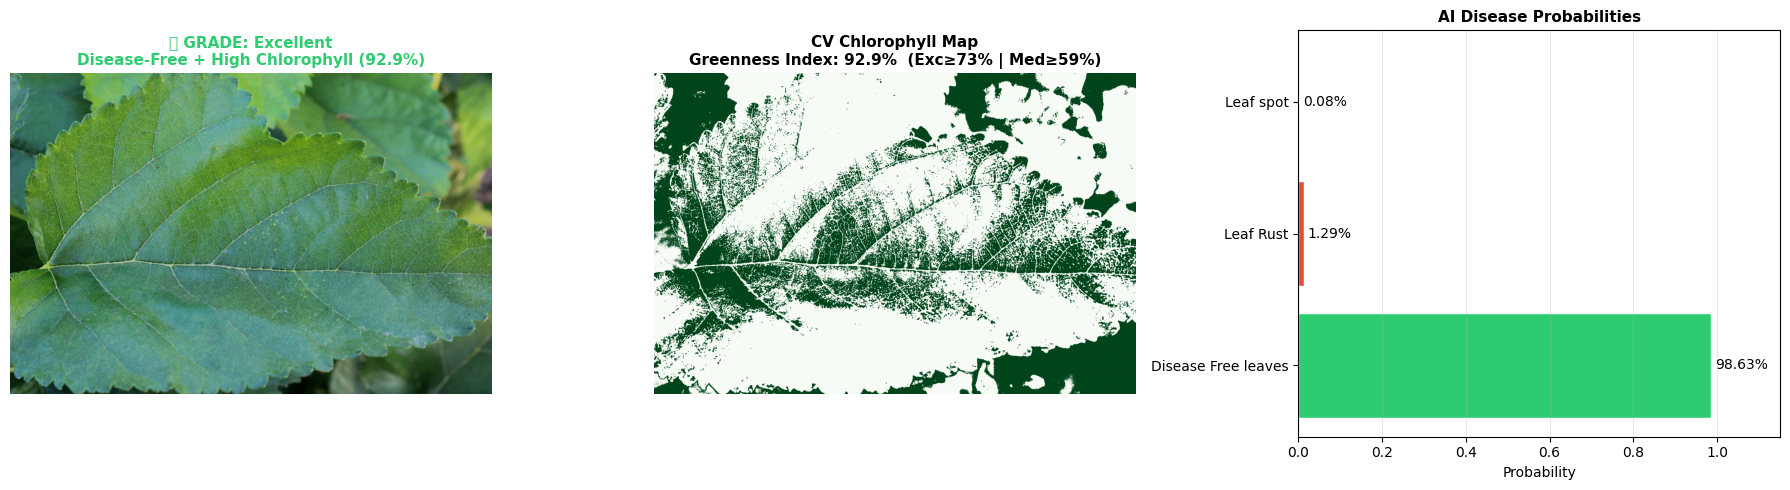


  HYBRID VERDICT : ✅ Excellent
  Disease-Free + High Chlorophyll (92.9%)
------------------------------------------------------------
  Leaf is HEALTHY + Peak Chlorophyll.
  → SUITABLE for silkworm feeding. Top-grade yield.

Input class: Leaf Rust


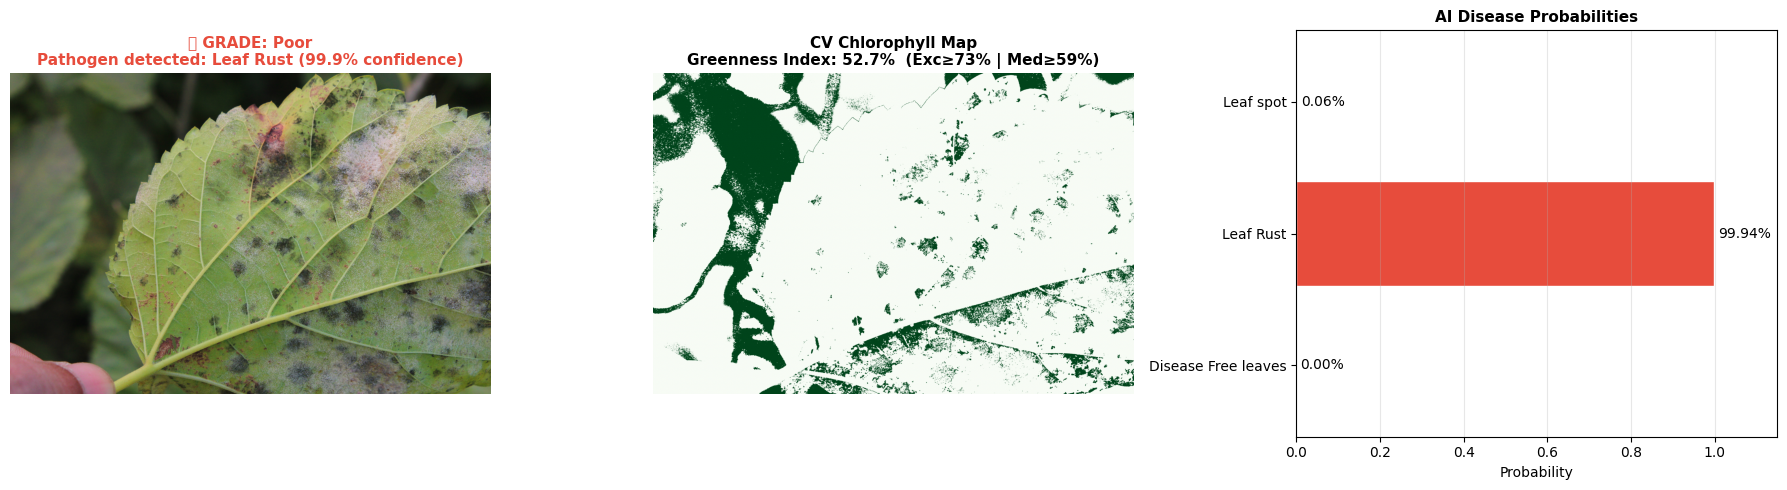


  HYBRID VERDICT : ❌ Poor
  Pathogen detected: Leaf Rust (99.9% confidence)
------------------------------------------------------------
  Pathogen detected: Leaf Rust.
  → NOT suitable. Leaf should be DISCARDED.

Input class: Leaf spot


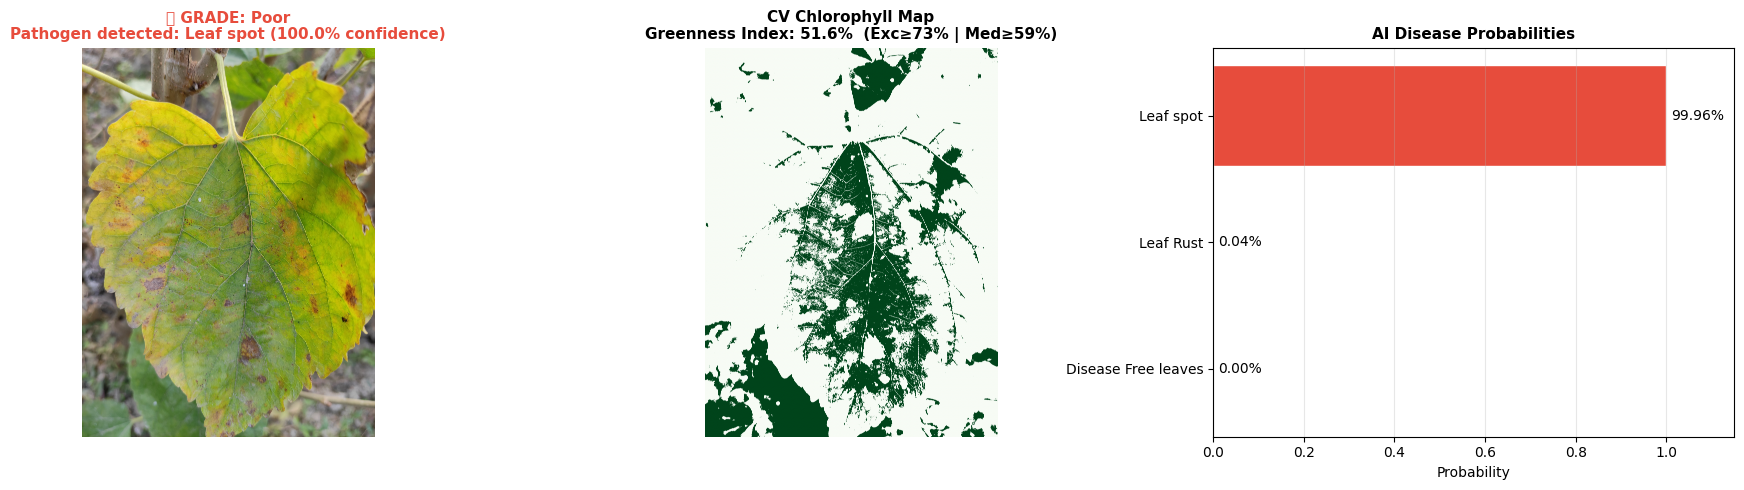


  HYBRID VERDICT : ❌ Poor
  Pathogen detected: Leaf spot (100.0% confidence)
------------------------------------------------------------
  Pathogen detected: Leaf spot.
  → NOT suitable. Leaf should be DISCARDED.


In [17]:
# -------------------------------------------------------
# Demo: pick one image from each class and run inference
# -------------------------------------------------------
demo_images = {}
for cls in CLASS_NAMES:
    cls_path = os.path.join(DATASET_ROOT, cls)
    imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if len(imgs) > 5:
        demo_images[cls] = os.path.join(cls_path, imgs[5])   # pick 6th image as demo

for cls_name, img_path in demo_images.items():
    print(f"\n{'='*60}")
    print(f"Input class: {cls_name}")
    result = predict_leaf_quality(
        image_path=img_path,
        model=model,
        class_indices=CLASS_INDICES,
        healthy_classes=HEALTHY_CLASSES,
        img_size=IMG_SIZE
    )
    display_prediction(img_path, result)


## 12. Predict Your Own Image

Upload any mulberry leaf image to `/kaggle/working/` and update the path below.

In [18]:
# -------------------------------------------------------
# CHANGE THIS PATH to your own uploaded image
# -------------------------------------------------------
MY_IMAGE_PATH = '/kaggle/working/my_leaf.jpg'

if os.path.exists(MY_IMAGE_PATH):
    result = predict_leaf_quality(
        image_path=MY_IMAGE_PATH,
        model=model,
        class_indices=CLASS_INDICES,
        healthy_classes=HEALTHY_CLASSES,
        img_size=IMG_SIZE
    )
    display_prediction(MY_IMAGE_PATH, result)
else:
    print(f"[INFO] No custom image found at '{MY_IMAGE_PATH}'.")
    print("Upload a leaf image to /kaggle/working/ and update MY_IMAGE_PATH above.")


[INFO] No custom image found at '/kaggle/working/my_leaf.jpg'.
Upload a leaf image to /kaggle/working/ and update MY_IMAGE_PATH above.


## 13. Save the Model

In [19]:
# Save model in native Keras format (recommended, .h5 is legacy and causes pickle errors)
model.save('/kaggle/working/mulberry_quality_classifier.keras')
print("Model saved as mulberry_quality_classifier.keras")

# Save metadata
import json as _json
meta = {
    'class_indices': CLASS_INDICES,
    'healthy_classes': HEALTHY_CLASSES,
    'diseased_classes': DISEASED_CLASSES,
    'img_size': IMG_SIZE,
    'greenness_thresholds': {
        'Excellent': 0.85,
        'Medium_lower': 0.60,
        'Poor_below': 0.60
    },
    'disease_confidence_threshold': 0.50
}
with open('/kaggle/working/model_metadata.json', 'w') as f:
    _json.dump(meta, f, indent=2)

print("Metadata saved to /kaggle/working/model_metadata.json")
fpath = '/kaggle/working/mulberry_quality_classifier.keras'
if os.path.exists(fpath):
    size_mb = os.path.getsize(fpath) / (1024 * 1024)
    print(f"  mulberry_quality_classifier.keras  ({size_mb:.1f} MB)")


Model saved as mulberry_quality_classifier.keras
Metadata saved to /kaggle/working/model_metadata.json
  mulberry_quality_classifier.keras  (31.5 MB)


## Summary

| Step | Detail |
|---|---|
| **Model** | EfficientNetB0 (ImageNet pre-trained) + custom head |
| **Training strategy** | 2-phase: warm-up (frozen base) → fine-tune (last 30 layers) |
| **Augmentations** | Rotation, flip, zoom, brightness, shear |
| **Output grades** | Excellent / Medium / Poor |
| **Grade logic** | Healthy + conf ≥ 0.80 → Excellent; Healthy + conf < 0.80 → Medium; Any disease → Poor |
| **Disease classes** | Red Rust, Leaf Spot, Powdery Mildew → all → Poor |
| **Saved artifacts** | `.keras`, `.h5`, `model_metadata.json` |

To reuse:
```python
import json, keras
model = keras.models.load_model('mulberry_quality_classifier.keras')
with open('model_metadata.json') as f:
    meta = json.load(f)
result = predict_leaf_quality(image_path, model, meta['class_indices'], meta['healthy_classes'])
```
